In [31]:
# =======================================================================================
#                       Etape 1 : Préparation et Transformation
# =======================================================================================

In [32]:
# ==================================
# 1. Importation des bibliothèques
# ==================================
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [33]:
# =========================================
# 2. Chargement et exploration des données
# =========================================
# Charger le dataset

client = bigquery.Client.from_service_account_json("key.json")

query = """
    SELECT
    *
    FROM `project-a0475dd2-d0c1-4640-aea.Sport_Metrics.mart_physical_condition`

"""

# Executer la requete
query_job = client.query(query)

# Transformer en dataframe
data = query_job.to_dataframe()

# Aperçu des premières lignes
print("Aperçu des données :\n", data.head())

# Informations générales sur les colonnes et les types de données
print("\nInformations sur le dataset :")
print(data.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
print(data.describe())

C:\Users\fafap\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Aperçu des données :
       Season   player_id                        session_id  Next_Match_ID  \
0  2019-2020  1681114057  FFS_20191020_1681114057_21900010       21900010   
1  2019-2020  1684823847  FFS_20191021_1684823847_21900010       21900010   
2  2019-2020  1681114057  FFS_20191021_1681114057_21900010       21900010   
3  2019-2020  1679015727  FFS_20191021_1679015727_21900010       21900010   
4  2019-2020  1657985451  FFS_20191021_1657985451_21900010       21900010   

      player_name  fi_last_training  rs_last_training  \
0    Abdoulaye Ba             55.11              3.01   
1  Yanis Belkacem             55.33              1.10   
2    Abdoulaye Ba             56.88              2.06   
3  Bryan Fournier             58.30              2.08   
4   Pierre Martin             61.32              0.96   

   recovery_needed_last_training  Fi_before_match  Focus_Level  ...  fg3_pct  \
0                              0             0.00          8.0  ...    0.000   
1           

In [34]:
# ==================================
# 3. Gestion des valeurs manquantes
# ==================================
# Vérification des valeurs manquantes
print(data.isnull().sum())

Season                           0
player_id                        0
session_id                       0
Next_Match_ID                    0
player_name                      0
fi_last_training                 0
rs_last_training                 0
recovery_needed_last_training    0
Fi_before_match                  0
Focus_Level                      0
Strength_Score                   0
Shooting_Accuracy_pct            0
Passing_Accuracy_pct             0
Performance_Score                0
Load_Intensity_Score             0
Injury_Risk                      0
fi_avg_7d                        0
fi_max_7d                        0
training_load_7d                 0
fi_avg_28d                       0
fi_max_28d                       0
training_load_28d                0
Place                            0
Position                         0
Start_position                   0
minutes_played                   0
Points                           0
fg_pct                           0
fg3_pct             

In [35]:
# ==================================================
# 4. Selection et nettoyage des données pertinentes
# ==================================================
# Sélection des données pertinentes
df = data.drop(columns = ['session_id','Focus_Level'])
df = df[df["Season"] == '2023-2024']
df = df[df["minutes_played"] >= 5]

# Aperçu des premières lignes
print("Aperçu des données pertinentes :\n", df.head())

Aperçu des données pertinentes :
          Season   player_id  Next_Match_ID      player_name  fi_last_training  \
5883  2023-2024  1659116774       22300013   Kevin Rousseau             50.69   
5884  2023-2024  1659116774       22300013   Kevin Rousseau             56.30   
5885  2023-2024  1664883672       22300013  Zacharie Dupont             59.62   
5886  2023-2024  1664883672       22300013  Zacharie Dupont             57.66   
5887  2023-2024  1655322242       22300013  Douglas Hermans             64.36   

      rs_last_training  recovery_needed_last_training  Fi_before_match  \
5883              2.26                              0              0.0   
5884              1.27                              0              0.0   
5885              2.33                              0              0.0   
5886              1.91                              0              0.0   
5887              1.16                              0              0.0   

      Strength_Score  Shooting_Acc

In [36]:
# =======================================================================================
#                       Etape 2 : Data Mining
# =======================================================================================

In [37]:
# =======================
# 1. Encodage des données
# =======================
# Encodage des colonnes catégoriques (sans relation d'ordre)

df["Position"] = LabelEncoder().fit_transform(df["Position"])

print(df["Position"].head())

5883    5
5884    5
5885    2
5886    2
5887    1
Name: Position, dtype: int64


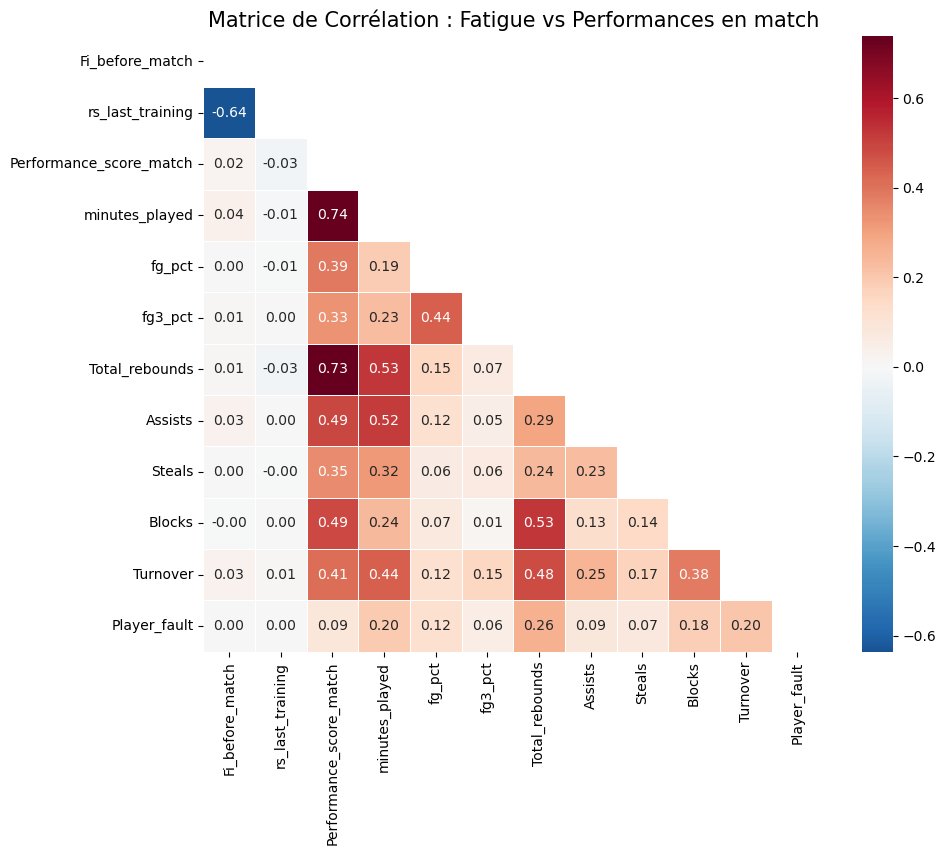

In [38]:
# ======================================
# 2. DÉTECTION DES PATTERNS ET TENDANCES
# ======================================
# Matrice de Corrélation

# On sélectionne uniquement les colonnes de performance
cols_interet = ['Fi_before_match', 'rs_last_training',
                'Performance_score_match', 'minutes_played',
                'fg_pct', 'fg3_pct', 'Total_rebounds',
                'Assists', 'Steals', 'Blocks',
                'Turnover', 'Player_fault']

df_corr = df[cols_interet].dropna()

# Calcul de la matrice (Pearson par défaut)
matrix = df_corr.corr()

plt.figure(figsize=(10, 8))

# Masque pour ne pas afficher la moitié supérieure (car c'est un miroir)
mask = np.triu(np.ones_like(matrix, dtype=bool))

# Affichage avec Seaborn
sns.heatmap(matrix, 
            mask=mask, 
            annot=True,      # Affiche les chiffres dans les cases
            cmap='RdBu_r',   # Bleu pour positif, Rouge pour négatif
            center=0, 
            fmt=".2f", 
            linewidths=.5)

plt.title("Matrice de Corrélation : Fatigue vs Performances en match", fontsize=15)
plt.show()

In [39]:
# =======================================================================================
#                       Etape 3 : Machine Learning
# =======================================================================================

In [40]:
# Séparation des variables explicatives 'indépendantes' (X) et de la variable cible 'dépendante' (y)
X = df[['minutes_played','Position','fi_last_training', 'Fi_before_match','training_load_7d']]
y = df["Performance_score_match"].values

# Division des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dimensions des ensembles :\nEntraînement : {X_train.shape}\nTest : {X_test.shape}")

Dimensions des ensembles :
Entraînement : (1298, 5)
Test : (325, 5)


In [41]:
# ===============================
# 1. Régression linéaire multiple
# ===============================

# Création du modèle
linear_model = LinearRegression()

# Ajustement du modèle
linear_model.fit(X_train, y_train)

# Prédictions
y_pred = linear_model.predict(X_test)

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Modèle linéaire :")
print(f'Erreur quadratique moyenne (MSE): {mse:.4f}')
print(f'Coefficient de détermination (R²): {r2:.4f}')
print(f'Erreur absolue moyenne (MAE): {mae:.2f}')

Modèle linéaire :
Erreur quadratique moyenne (MSE): 52.7038
Coefficient de détermination (R²): 0.5581
Erreur absolue moyenne (MAE): 5.71


In [42]:
# ≈ 56 % de la variation de la performance par match

In [43]:
# =================================
# 2. Arbre de décision : Régression
# =================================

# Construction et ajustement de l'arbre de régression
tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = tree_model.predict(X_test)

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Arbre de décision :")
print(f'Erreur quadratique moyenne (MSE): {mse:.4f}')
print(f'Coefficient de détermination (R²): {r2:.4f}')
print(f'Erreur absolue moyenne (MAE): {mae:.2f}')

Arbre de décision :
Erreur quadratique moyenne (MSE): 50.8715
Coefficient de détermination (R²): 0.5735
Erreur absolue moyenne (MAE): 5.45


In [44]:
# ≈ 57 % de la variation de la performance par match

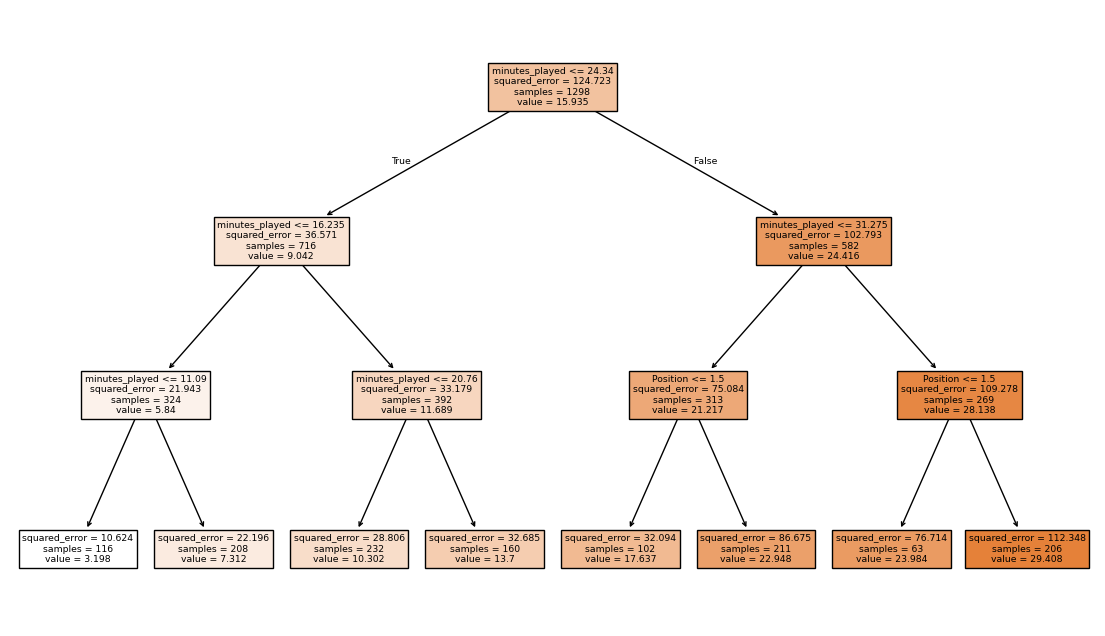

In [45]:
# Visualisation de l'arbre
plt.figure(figsize=(14, 8))
plot_tree(tree_model, feature_names=X.columns, class_names=y.unique(), filled=True)
plt.show()

In [46]:
# =================================
# 3. Forêts aléatoires : Régression
# =================================

# Construction et ajustement de la forêt aléatoire
rf_model = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred = rf_model.predict(X_test)

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Forêt aléatoire :")
print(f'Erreur quadratique moyenne (MSE): {mse:.4f}')
print(f'Coefficient de détermination (R²): {r2:.4f}')
print(f'Erreur absolue moyenne (MAE): {mae:.2f}')

Forêt aléatoire :
Erreur quadratique moyenne (MSE): 40.3032
Coefficient de détermination (R²): 0.6621
Erreur absolue moyenne (MAE): 4.80


C:\Users\fafap\AppData\Local\Temp\ipykernel_16924\1463855706.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


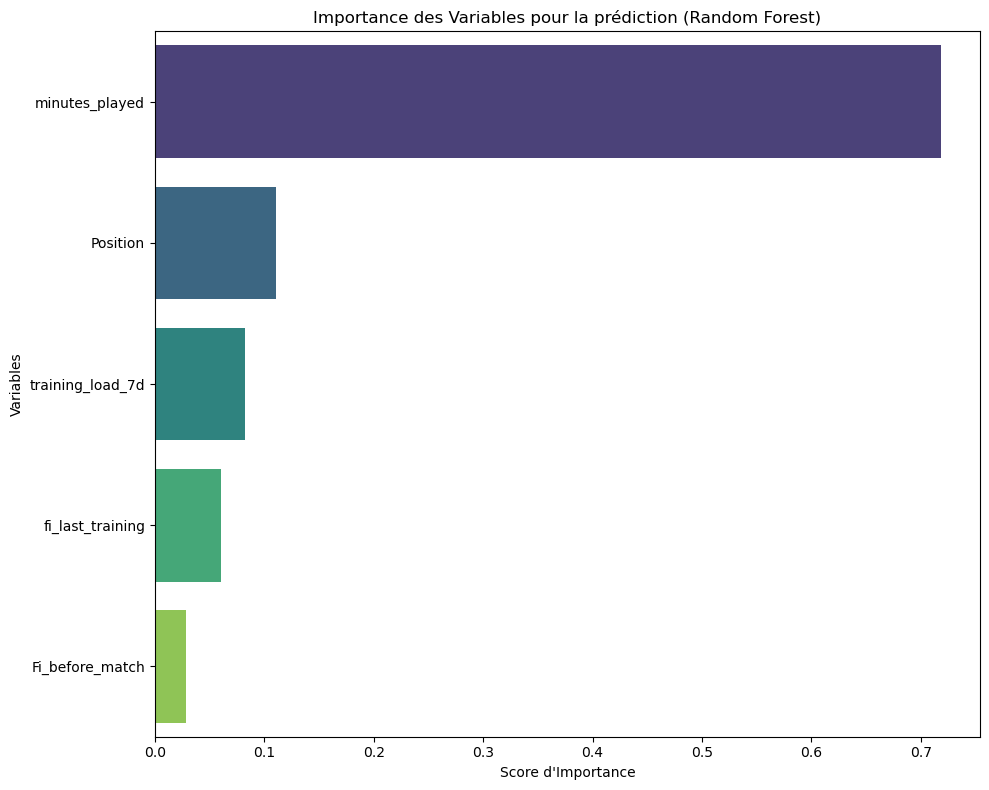

In [47]:
# Analyse et Visualisation de l'Importance des Caractéristiques
importances = rf_model.feature_importances_
feature_names = X.columns

# Création d'un DataFrame trié
df_importances = pd.DataFrame({
    'Variable': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualisation avec Seaborn
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Variable',
    data=df_importances,
    palette='viridis'    # On applique une palette de couleurs
)
plt.title("Importance des Variables pour la prédiction (Random Forest)")
plt.xlabel("Score d'Importance")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

Les minutes jouées constituent le facteur explicatif dominant de la performance par match (=70 % d’importance),tandis que les indicateurs de fatigue contribuent de manière secondaire mais non négligeable (=20 %).

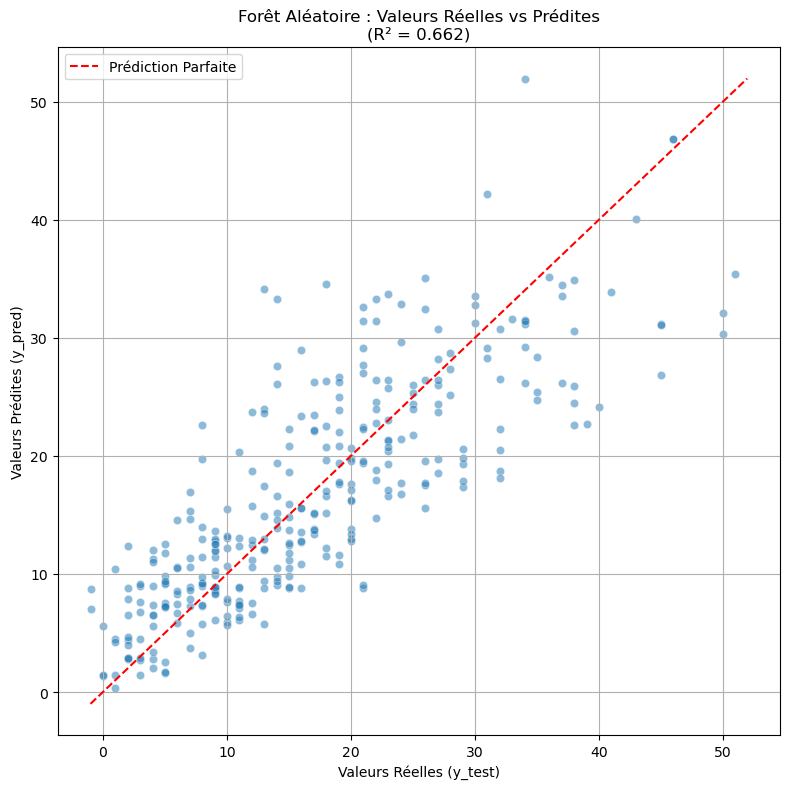

In [48]:
# Graphique : Valeurs Réelles vs Valeurs Prédites
plt.figure(figsize=(8, 8))

# Nuage de points
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

# Ligne diagonale de référence (y = x)
# Si le modèle était parfait, tous les points seraient sur cette ligne.
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Prédiction Parfaite')

plt.title(f"Forêt Aléatoire : Valeurs Réelles vs Prédites\n(R² = {r2:.3f})")
plt.xlabel("Valeurs Réelles (y_test)")
plt.ylabel("Valeurs Prédites (y_pred)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
# = 66 % de la variation de la performance par match

In [50]:
# ===========
# 4. XGBoost
# ===========

# 1. Construction et ajustement du modèle XGBoost
xgb_model = XGBRegressor(n_estimators=188, max_depth=4, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

# 2. Prédictions sur l'ensemble de test
y_pred = xgb_model.predict(X_test)

# 3. Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"XGBoost :")
print(f'Erreur quadratique moyenne (MSE): {mse:.4f}')
print(f'Coefficient de détermination (R²): {r2:.4f}')
print(f'Erreur absolue moyenne (MAE): {mae:.2f}')

XGBoost :
Erreur quadratique moyenne (MSE): 40.3049
Coefficient de détermination (R²): 0.6621
Erreur absolue moyenne (MAE): 4.91


In [51]:
# 4. Utilisation de EARLY STOPPING:
# Pour trouver automatiquement le nombre d'arbres optimal (n_estimators),
# sans surapprentissage (overfitting).

# Préparation d'un jeu de validation INTERNE au training
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

# 5. Construction du modèle avec des paramètres optimisés
# On augmente n_estimators car l'early stopping l'arrêtera avant.
xgb_model = XGBRegressor(
    n_estimators=1000,          # Nombre maximum d'arbres
    learning_rate=0.05,         # Taux d'apprentissage lent
    max_depth=4,                # Profondeur faible
    subsample=0.8,              # Fraction des données pour chaque arbre
    colsample_bytree=0.8,       # Fraction des colonnes pour chaque arbre
    random_state=42,
    n_jobs=-1,                  # Utilise tous les cœurs
    verbosity=1,
    early_stopping_rounds=50,   # S'arrête si pas d'amélioration pendant 50 rounds
    eval_metric="mae"            # Métrique de surveillance (Mean Absolute Error)
)


# 6. Ajustement du modèle
# Le modèle s'entraîne sur (X_train_final) et surveille l'erreur sur (X_val).
# Il s'arrête si l'erreur sur X_val ne diminue plus pendant 50 rounds.
xgb_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_val, y_val)], # Jeu surveillé
    verbose=False               # Mettre à True pour voir les détails par itération
)

# 7. On récupère le nombre d'arbres optimal trouvé
best_iteration = xgb_model.best_iteration
print(f"Entraînement terminé.")
print(f"Nombre d'arbres optimal trouvé par Early Stopping : {best_iteration}")


# 8. Re-Prédictions sur l'ensemble de test
y_pred = xgb_model.predict(X_test)

# 9. Évaluation du modèle optimisé Métriques sur le hold-out test set
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nRésultats XGBoost optimisé:")
print(f'MSE: {mse:.2f}')
print(f'R² : {r2:.4f}')
print(f'MAE: {mae:.2f}')

Entraînement terminé.
Nombre d'arbres optimal trouvé par Early Stopping : 177

Résultats XGBoost optimisé:
MSE: 39.55
R² : 0.6684
MAE: 4.87


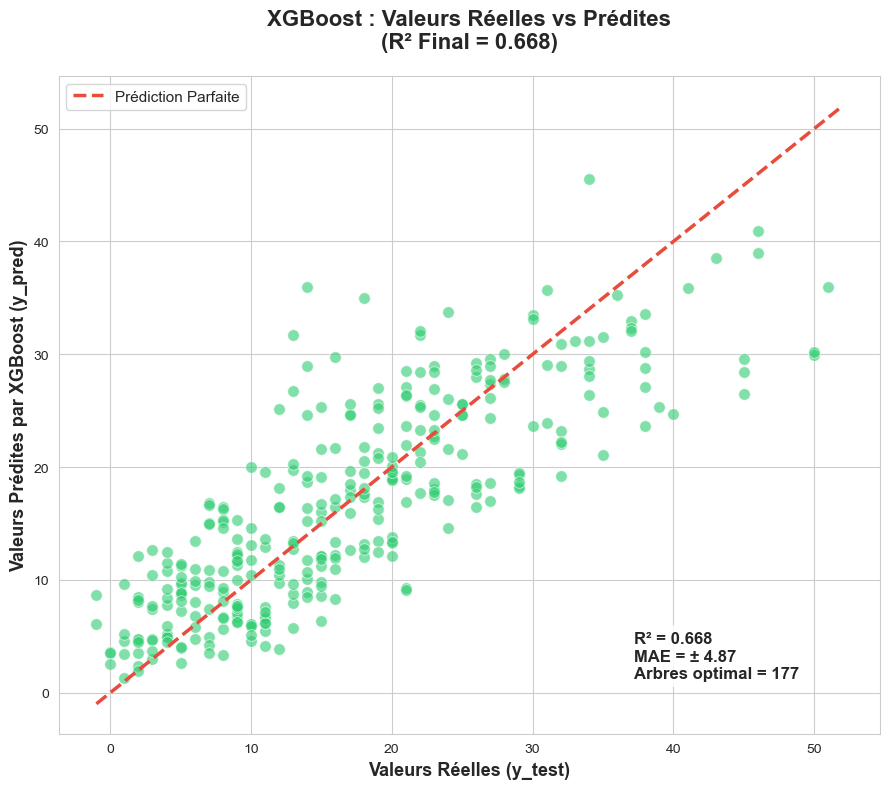

In [52]:
# 10. Visualisation des résultats (RÉEL VS PRÉDIT)

plt.figure(figsize=(9, 8))
sns.set_style("whitegrid")

# Nuage de points
sns.scatterplot(x=y_test, y=y_pred, color='#2ecc71', edgecolor='w', alpha=0.6, s=70)

# Ligne de prédiction parfaite (y=x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val * 0.98, max_val * 1.02], [min_val * 0.98, max_val * 1.02], 
         color='#e74c3c', linestyle='--', linewidth=2.5, label='Prédiction Parfaite')

# Titres et labels
plt.title(f"XGBoost : Valeurs Réelles vs Prédites\n(R² Final = {r2:.3f})", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Valeurs Réelles (y_test)", fontsize=13, fontweight='bold')
plt.ylabel("Valeurs Prédites par XGBoost (y_pred)", fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)

# Encadré des métriques
textstr = '\n'.join((
    f'R² = {r2:.3f}',
    f'MAE = ± {mae:.2f}',
    f'Arbres optimal = {best_iteration}'
))
props = dict(boxstyle='round', facecolor='white', alpha=0.9)
plt.text(0.70, 0.08, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='bottom', bbox=props, fontweight='bold')

plt.tight_layout()
plt.show()

In [53]:
# ≈ 66 % de la variation de la performance par match

Conclusion:

On constate que les minutes jouées constituent le facteur explicatif dominant de la performance par match (70 % d’importance),tandis que les indicateurs de fatigue contribuent de manière secondaire mais non négligeable (20 %).

On remarque que le modèle forêt atteint déjà la précision max (R² ≈ 0.662) et une erreur absolue (MAE = 4.8) que le modèle de XGBoost, alors dans un soucis de minimiser l'impact technique (gain de productivité), nous optons pour le modèle de forêt pour nos prédictions sur l'impact fatigue sur les performances.